In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "distilgpt2"
device = torch.device("cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
# Output: Parameters: 81,912,576

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded!
Parameters: 81,912,576


In [2]:
import torch

#small set of general knowledge prompts
general_prompts = [
    "The capital of France is",
    "Water boils at 100 degrees",
    "The speed of light is approximately",
    "Albert Einstein was born in",
    "The human body has 206",
    "Python is a programming language",
    "The Earth orbits around the",
    "Shakespeare wrote the play",
]

def get_perplexity(prompts, model, tokenizer):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for text in prompts:
            inputs = tokenizer(
                text, return_tensors="pt",
                padding=True, truncation=True, max_length=64
            )
            outputs = model(**inputs, labels=inputs["input_ids"])
            total_loss += outputs.loss.item()
    return round(total_loss / len(prompts), 4)

# Baseline, before any fine-tuning
baseline_perplexity = get_perplexity(general_prompts, model, tokenizer)
print(f"Baseline perplexity: {baseline_perplexity}")
# Lower = model finds general text familiar

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline perplexity: 5.7156


In [3]:
from datasets import load_dataset

dataset = load_dataset("medalpaca/medical_meadow_medqa", split="train")

dataset = dataset.select(range(500))

print(dataset[0])

{'input': "Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?? \n{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Ciprofloxacin', 'D': 'Doxycycline', 'E': 'Nitrofurantoin'},", 'instruction': 'Please answer with one of the option in the bracket', 'output': 'E: Nitrofurantoin'}


In [4]:
def format_example(example):
    text = f"Question: {example['input']}\nAnswer: {example['output']}"
    return {"text": text}

dataset = dataset.map(format_example)

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=128,
        padding="max_length"
    )

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.remove_columns(
    [c for c in tokenized.column_names if c not in
     ["input_ids", "attention_mask"]]
)
tokenized.set_format("torch")

print(f"Training examples: {len(tokenized)}")

Training examples: 500


In [8]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

training_args = TrainingArguments(
    output_dir="./medical_finetuned",
    num_train_epochs=3,          
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    save_steps=999999,          
    logging_steps=50,
    report_to="none",           
    use_cpu=True   
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=data_collator
)

print("Fine-tuning on medical data")
trainer.train()
print("Done")

Fine-tuning on medical data...


Step,Training Loss
50,3.076720
100,2.661539
150,2.490393


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done!


In [9]:
finetuned_perplexity = get_perplexity(general_prompts, model, tokenizer)

print(f"\nResults:")
print(f"  Before fine-tuning: {baseline_perplexity}")
print(f"  After fine-tuning:  {finetuned_perplexity}")
print(f"  Change:             +{round(finetuned_perplexity - baseline_perplexity, 4)}")
print(f"\n  Higher perplexity = model finds general text less familiar = forgetting")


Results:
  Before fine-tuning: 5.7156
  After fine-tuning:  5.914
  Change:             +0.1984

  Higher perplexity = model finds general text less familiar = forgetting


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

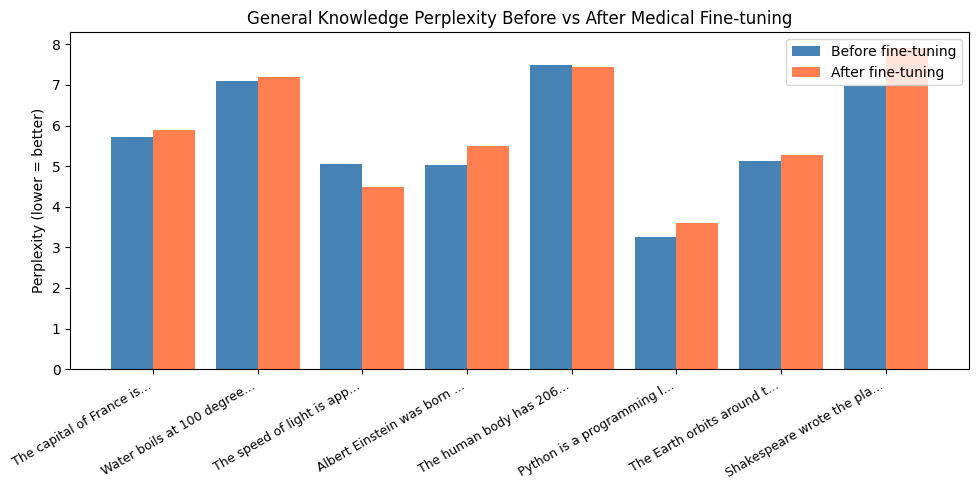

In [10]:
import matplotlib.pyplot as plt

before_scores = []
after_scores  = []

model_copy_before = AutoModelForCausalLM.from_pretrained("distilgpt2")  
model_copy_before.eval()

for prompt in general_prompts:
    before_scores.append(get_perplexity([prompt], model_copy_before, tokenizer))
    after_scores.append( get_perplexity([prompt], model,             tokenizer))

x = range(len(general_prompts))
labels = [p[:25] + "..." for p in general_prompts]  # truncate for display

plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], before_scores, width=0.4, label='Before fine-tuning', color='steelblue')
plt.bar([i + 0.2 for i in x], after_scores,  width=0.4, label='After fine-tuning',  color='coral')
plt.xticks(list(x), labels, rotation=30, ha='right', fontsize=9)
plt.ylabel('Perplexity (lower = better)')
plt.title('General Knowledge Perplexity Before vs After Medical Fine-tuning')
plt.legend()
plt.tight_layout()
plt.savefig('llm_forgetting.png', dpi=150)
plt.show()